<a href="https://colab.research.google.com/github/fgakindunimsara/HeatX-Optimizer/blob/main/First_Approximation_of_a_Vibratory_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Question 5**

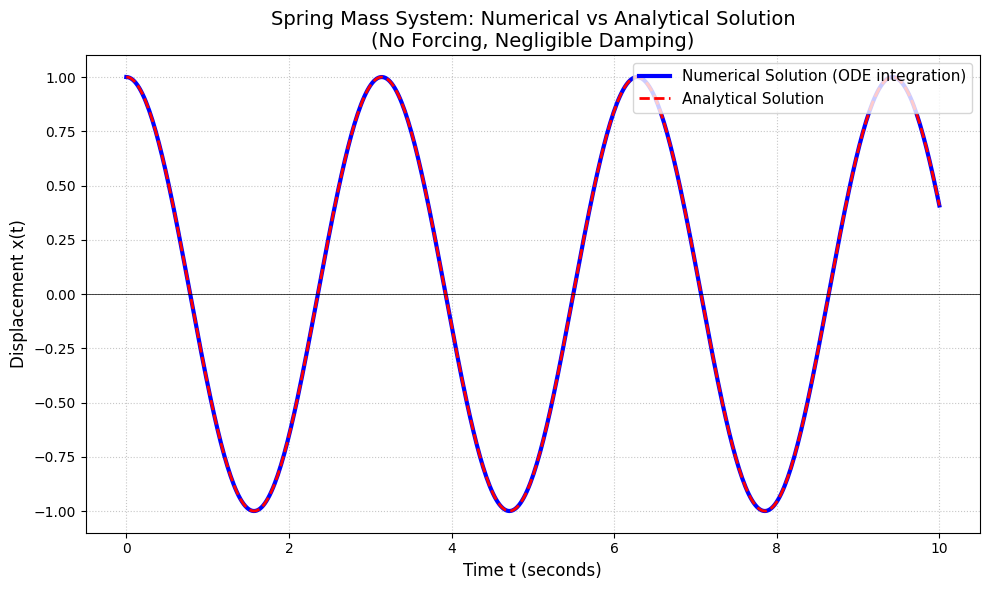

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

omega_n = 2.0


def unforced_undamped_system(X, t):
    x1, x2 = X
    dx1dt = x2
    dx2dt = -(omega_n**2) * x1
    return [dx1dt, dx2dt]


x_0 = 1.0
v_0 = 0.0
X0 = [x_0, v_0]

t = np.linspace(0, 10, 500)

X_num = odeint(unforced_undamped_system, X0, t)
x_numerical = X_num[:, 0]

x_analytical = x_0 * np.cos(omega_n * t) + (v_0 / omega_n) * np.sin(omega_n * t)

plt.figure(figsize=(10, 6))

plt.plot(t, x_numerical, 'b-', label='Numerical Solution (ODE integration)', linewidth=3)

plt.plot(t, x_analytical, 'r--', label='Analytical Solution', linewidth=2)

plt.title('Spring Mass System: Numerical vs Analytical Solution\n(No Forcing, Negligible Damping)', fontsize=14)
plt.xlabel('Time t (seconds)', fontsize=12)
plt.ylabel('Displacement x(t)', fontsize=12)
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('simulation_plot.png')
plt.show()

**Question 7**

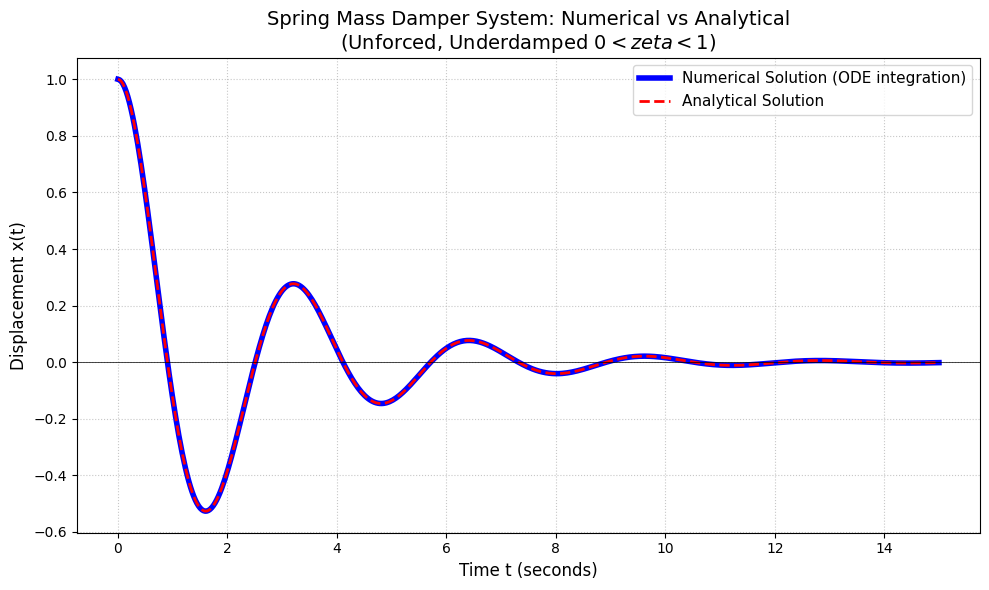

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

omega_n = 2.0
zeta = 0.2
omega_d = omega_n * np.sqrt(1 - zeta**2)

def underdamped_system(X, t):
    x1, x2 = X
    dx1dt = x2
    dx2dt = -(omega_n**2) * x1 - 2 * zeta * omega_n * x2
    return [dx1dt, dx2dt]

x_0 = 1.0
v_0 = 0.0
X0 = [x_0, v_0]

t = np.linspace(0, 15, 500)

X_num = odeint(underdamped_system, X0, t)
x_numerical = X_num[:, 0]

c1 = x_0
c2 = (v_0 + zeta * omega_n * x_0) / omega_d

x_analytical = np.exp(-zeta * omega_n * t) * (c1 * np.cos(omega_d * t) + c2 * np.sin(omega_d * t))

plt.figure(figsize=(10, 6))

plt.plot(t, x_numerical, 'b-', label='Numerical Solution (ODE integration)', linewidth=4)

plt.plot(t, x_analytical, 'r--', label='Analytical Solution', linewidth=2)

plt.title('Spring Mass Damper System: Numerical vs Analytical\n(Unforced, Underdamped $0 < zeta < 1$)', fontsize=14)
plt.xlabel('Time t (seconds)', fontsize=12)
plt.ylabel('Displacement x(t)', fontsize=12)
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('underdamped_simulation.png')
plt.show()

**Question 9**

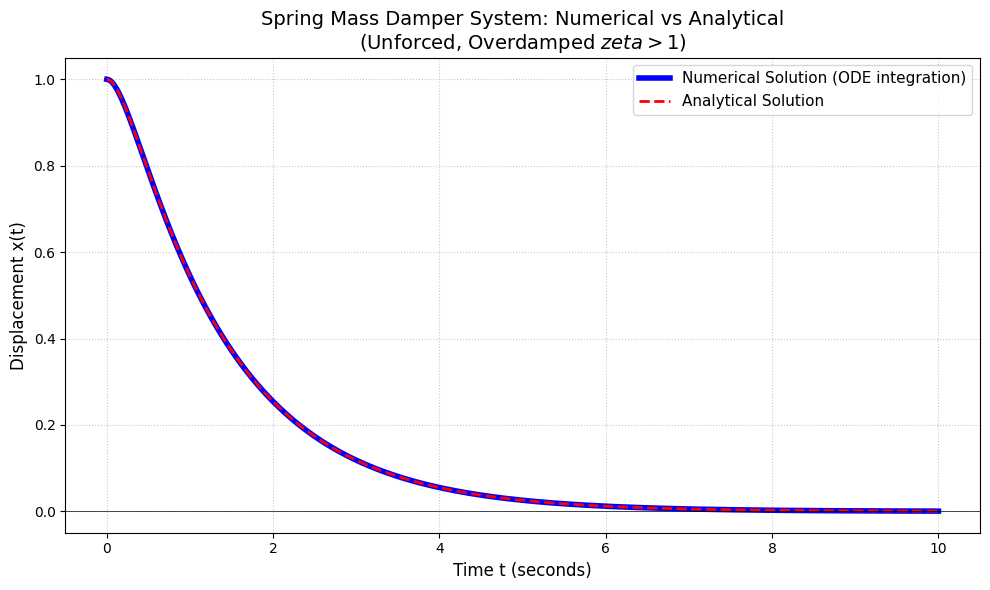

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


omega_n = 2.0
zeta = 1.5

lambda_1 = omega_n * (zeta - np.sqrt(zeta**2 - 1))
lambda_2 = omega_n * (zeta + np.sqrt(zeta**2 - 1))


def overdamped_system(X, t):
    x1, x2 = X
    dx1dt = x2
    dx2dt = -(omega_n**2) * x1 - 2 * zeta * omega_n * x2
    return [dx1dt, dx2dt]

x_0 = 1.0
v_0 = 0.0
X0 = [x_0, v_0]

t = np.linspace(0, 10, 500)

X_num = odeint(overdamped_system, X0, t)
x_numerical = X_num[:, 0]

c11 = (v_0 + lambda_2 * x_0) / (lambda_2 - lambda_1)
c12 = -(v_0 + lambda_1 * x_0) / (lambda_2 - lambda_1)

x_analytical = c11 * np.exp(-lambda_1 * t) + c12 * np.exp(-lambda_2 * t)

plt.figure(figsize=(10, 6))

plt.plot(t, x_numerical, 'b-', label='Numerical Solution (ODE integration)', linewidth=4)

plt.plot(t, x_analytical, 'r--', label='Analytical Solution', linewidth=2)

plt.title('Spring Mass Damper System: Numerical vs Analytical\n(Unforced, Overdamped $zeta > 1$)', fontsize=14)
plt.xlabel('Time t (seconds)', fontsize=12)
plt.ylabel('Displacement x(t)', fontsize=12)
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('overdamped_simulation.png')
plt.show()

**Question 10**

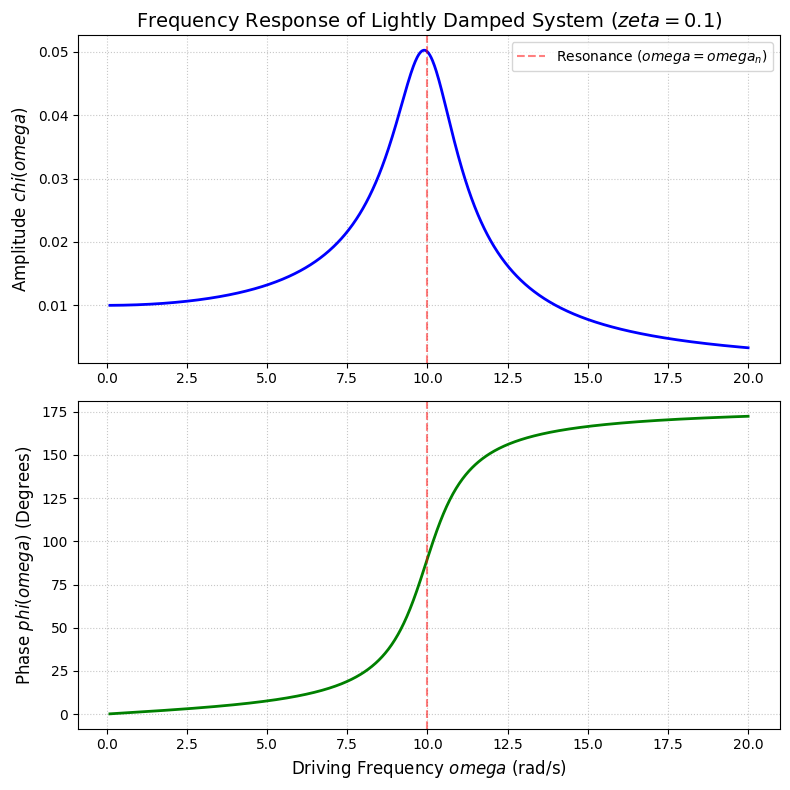

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


M = 1.0
omega_n = 10.0
zeta = 0.1

omega = np.linspace(0.1, 20, 1000)


chi_numerator = 1 / M
chi_denominator = np.sqrt((omega_n**2 - omega**2)**2 + 4 * zeta**2 * omega**2 * omega_n**2)
chi_omega = chi_numerator / chi_denominator

phi_omega = np.arctan2(2 * zeta * omega * omega_n, omega_n**2 - omega**2)

phi_deg = np.degrees(phi_omega)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))


ax1.plot(omega, chi_omega, 'b-', linewidth=2)
ax1.set_title('Frequency Response of Lightly Damped System ($zeta = 0.1$)', fontsize=14)
ax1.set_ylabel('Amplitude $chi(omega)$', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.axvline(omega_n, color='r', linestyle='--', alpha=0.5, label='Resonance ($omega = omega_n$)')
ax1.legend()

ax2.plot(omega, phi_deg, 'g-', linewidth=2)
ax2.set_xlabel('Driving Frequency $omega$ (rad/s)', fontsize=12)
ax2.set_ylabel('Phase $phi(omega)$ (Degrees)', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.axvline(omega_n, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('frequency_response_plot.png')
plt.show()